# What did fine-tuning cost you?

The Yoda adapter taught Phi-3 a new style. This notebook asks the question the style
metrics cannot: **did it make the model worse at everything else?**

This is the question a retrieval-based comparison cannot ask. RAG and CAG add context and
leave the weights untouched, so they cannot damage the model. QLoRA edits it. That
asymmetry is the whole point of this notebook.

## Two axes

| Axis | Measured on | Metric |
| --- | --- | --- |
| **Style** | `yoda_external_test.csv` (20 held-out sentences) | BERTScore F1, chrF |
| **Capability** | `phi3_capability_probe.csv` (40 general items) | exact / keyword / format accuracy |

The adapter's contribution is scaled at inference by a factor **alpha**, so we can sweep
it from 0 (pure base model) up past 1.0 (stronger than trained) and watch the two axes
trade against each other. The result is a curve, not a verdict.

## Before you start

- Runtime &rarr; Change runtime type &rarr; **T4 GPU**.
- Upload `yoda_external_test.csv`, `phi3_capability_probe.csv`, and your trained adapter
  folder (from Chapter 0's `trainer.save_model(...)`).
- The base model, quantization config, and decoding settings match
  `yoda_model_evaluation_colab.ipynb` exactly, so numbers from the two notebooks are
  directly comparable. Do not change them.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q transformers==4.56.1 peft==0.17.0 accelerate==1.10.0 bitsandbytes==0.47.0 datasets==4.0.0 evaluate bert-score sacrebleu pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.9/503.9 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.7/374.7 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 13.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires hu

In [3]:
import os
import re
import string

import numpy as np
import pandas as pd
import torch
import evaluate
from peft import PeftModel
from sacrebleu import corpus_chrf
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

torch.manual_seed(42)

# ---- Paths and settings ------------------------------------------------
REPO_ID = "microsoft/Phi-3-mini-4k-instruct"
ADAPTER_PATH = "/content/drive/MyDrive/344/344-FA26-Students/344-FA26-code/local-phi3-mini-yoda-adapter"   # TODO: your adapter folder or HF repo id
STYLE_CSV = "/content/drive/MyDrive/344/344-FA26-Students/344-FA26-code/yoda_external_test.csv"
PROBE_CSV = "/content/drive/MyDrive/344/344-FA26-Students/344-FA26-code/phi3_capability_probe.csv"
RESULTS_PATH = "/content/drive/MyDrive/344/code/QLoRA-SFT-Yoda-Genz/yoda_alignment_tax_results-demo.csv"

ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]   # adapter strength sweep
MAX_NEW_TOKENS = 64                          # same as the 3-condition notebook
# ------------------------------------------------------------------------

assert os.path.isfile(STYLE_CSV), f"Upload the style test set to {STYLE_CSV}"
assert os.path.isfile(PROBE_CSV), f"Upload the capability probe to {PROBE_CSV}"

YODA_SYSTEM_PROMPT = """
You rewrite ordinary English sentences in Yoda's distinctive speaking style.

Rules:
- Preserve the original meaning.
- Use Yoda-like inverted sentence structure.
- Keep the response concise.
- You may occasionally use expressions such as "Hmm" or "Hrrmm."
- Return only the rewritten sentence.
- Do not explain your answer.
""".strip()

In [4]:
# Identical configuration to yoda_model_evaluation_colab.ipynb - do not change,
# or the numbers stop being comparable across the two notebooks.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

base_model = AutoModelForCausalLM.from_pretrained(
    REPO_ID,
    device_map="auto",
    quantization_config=bnb_config,
)

tokenizer = AutoTokenizer.from_pretrained(REPO_ID)
tokenizer.pad_token = tokenizer.unk_token
tokenizer.pad_token_id = tokenizer.unk_token_id

print(f"Model memory footprint: {base_model.get_memory_footprint() / 1e6:.1f} MB")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Model memory footprint: 2206.3 MB


In [5]:
style_df = pd.read_csv(STYLE_CSV)
probe_df = pd.read_csv(PROBE_CSV)

assert {"sentence", "translation_extra"}.issubset(style_df.columns)
assert {"prompt", "check_type", "expected", "category"}.issubset(probe_df.columns)

style_sentences = style_df["sentence"].tolist()
style_references = style_df["translation_extra"].tolist()

print(f"Style test set:     {len(style_df)} sentences")
print(f"Capability probe:   {len(probe_df)} items")
print(probe_df["category"].value_counts().to_string())

Style test set:     20 sentences
Capability probe:   40 items
category
factual        12
arithmetic     10
format          8
instruction     6
reasoning       4


In [6]:
def _norm(text):
    text = text.lower().strip()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return " ".join(text.split())


def score_probe(output, check_type, expected):
    """True if the model's output satisfies this probe item.

    exact        - normalised output equals expected
    keyword      - any '|'-separated alternative appears
    all_keywords - every ';'-separated term appears
    word_count   - output has exactly N words
    numeric      - expected appears among the numbers in the output
    """
    low = output.lower()
    if check_type == "exact":
        return _norm(output) == _norm(expected)
    if check_type == "keyword":
        return any(alt.strip() in low for alt in expected.split("|"))
    if check_type == "all_keywords":
        return all(term.strip() in low for term in expected.split(";"))
    if check_type == "word_count":
        return len(output.split()) == int(expected)
    if check_type == "numeric":
        found = re.findall(r"-?\d+(?:\.\d+)?", output.replace(",", ""))
        return expected in found
    raise ValueError(f"unknown check_type: {check_type}")


# Quick self-test of the scorer before any GPU time is spent on it.
_cases = [
    ("17 times 4 is 68.", "numeric", "68", True),
    ("The answer is 1,800", "numeric", "1800", True),
    ("Sydney is the capital.", "keyword", "canberra", False),
    ("Red, blue and yellow.", "all_keywords", "red;blue;yellow", True),
    ("Here are exactly three words", "word_count", "3", False),
    ("Yes.", "exact", "yes", True),
]
assert all(score_probe(o, c, e) == want for o, c, e, want in _cases)
print("scorer self-test passed")

scorer self-test passed


In [7]:
# Copied verbatim from yoda_model_evaluation_colab.ipynb so both notebooks decode
# identically. do_sample=False keeps every condition deterministic.
def build_messages(sentence, system_prompt=None):
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": sentence})
    return messages


def generate_response(model, tokenizer, sentence, system_prompt=None,
                      max_new_tokens=MAX_NEW_TOKENS):
    messages = build_messages(sentence, system_prompt)

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)

    prompt_length = inputs["input_ids"].shape[1]
    model.eval()

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated_tokens = output[0, prompt_length:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()


def run_probe(model, probe_frame):
    """Generate an answer for every probe item and score it."""
    outputs = [generate_response(model, tokenizer, p) for p in probe_frame["prompt"]]
    correct = [
        score_probe(out, row.check_type, str(row.expected))
        for out, row in zip(outputs, probe_frame.itertuples())
    ]
    return outputs, correct

In [8]:
# STEP 1: calibrate the probe against the BASE model.
#
# We are measuring degradation, so every item must be one the base model already gets
# right. An item the base fails has no headroom to fall and only adds noise. Drop them.
base_probe_outputs_all, base_probe_correct_all = run_probe(base_model, probe_df)

probe_df["base_correct"] = base_probe_correct_all
probe_df["base_output"] = base_probe_outputs_all

dropped = probe_df.loc[~probe_df["base_correct"], ["category", "prompt", "base_output"]]
probe = probe_df[probe_df["base_correct"]].reset_index(drop=True)

print(f"Base model answered {len(probe)}/{len(probe_df)} probe items correctly.")
print(f"Keeping {len(probe)} calibrated items; dropping {len(dropped)}.\n")
if len(dropped):
    print("Dropped (base model could not do these, so they cannot show degradation):")
    display(dropped)

assert len(probe) >= 15, (
    f"Only {len(probe)} usable probe items. Too few to resolve an effect - "
    "add easier items to phi3_capability_probe.csv and re-run."
)
print(probe["category"].value_counts().to_string())

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base model answered 35/40 probe items correctly.
Keeping 35 calibrated items; dropping 5.

Dropped (base model could not do these, so they cannot show degradation):


,category,prompt,base_output
8,arithmetic,What is the sum of 234 and 566?,"To find the sum of 234 and 566, you simply add..."
22,format,Reply with exactly three words.,"""Please specify."""
23,format,Reply with exactly five words.,"""Expressing gratitude, appreciating kindness."""
29,format,Reply with exactly four words.,"""Please respond concisely."""
32,instruction,Name three of the four seasons of the year.,Three of the four seasons of the year are spri...


category
factual        12
arithmetic      9
format          5
instruction     5
reasoning       4


In [9]:
bertscore = evaluate.load("bertscore")


def score_style(predictions):
    """Mean BERTScore F1 and corpus chrF against the Yoda references."""
    scores = bertscore.compute(
        predictions=predictions,
        references=style_references,
        lang="en",
        model_type="distilbert-base-uncased",
    )
    return float(np.mean(scores["f1"])), float(corpus_chrf(predictions, [style_references]).score)


# IMPORTANT: run every base-model measurement BEFORE loading the adapter.
# PeftModel injects adapter layers into base_model in place, so afterwards the
# name `base_model` is no longer the unmodified model.
base_style_plain = [generate_response(base_model, tokenizer, s) for s in style_sentences]
base_style_prompted = [
    generate_response(base_model, tokenizer, s, system_prompt=YODA_SYSTEM_PROMPT)
    for s in style_sentences
]

base_bert_plain, base_chrf_plain = score_style(base_style_plain)
base_bert_prompted, base_chrf_prompted = score_style(base_style_prompted)
base_capability = float(np.mean(probe["base_correct"]))

print(f"Base, no prompt     - BERTScore {base_bert_plain:.4f}  chrF {base_chrf_plain:.2f}")
print(f"Base, Yoda prompt   - BERTScore {base_bert_prompted:.4f}  chrF {base_chrf_prompted:.2f}")
print(f"Base capability     - {base_capability:.3f} (1.000 by construction after calibration)")

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Base, no prompt     - BERTScore 0.7832  chrF 36.63
Base, Yoda prompt   - BERTScore 0.9034  chrF 75.05
Base capability     - 1.000 (1.000 by construction after calibration)


In [10]:
try:
    from peft.tuners.lora import LoraLayer
except ImportError:                      # layout changed in some peft versions
    from peft.tuners.lora.layer import LoraLayer

model_ft = PeftModel.from_pretrained(base_model, ADAPTER_PATH)

# Each LoRA layer keeps a `scaling` factor (lora_alpha / r). Multiplying it by alpha
# dials the adapter's contribution at inference time - no retraining involved.
ORIGINAL_SCALING = {}


def capture_scaling(model, adapter="default"):
    ORIGINAL_SCALING.clear()
    for name, module in model.named_modules():
        if isinstance(module, LoraLayer) and adapter in module.scaling:
            ORIGINAL_SCALING[name] = module.scaling[adapter]
    return len(ORIGINAL_SCALING)


def set_lora_scale(model, alpha, adapter="default"):
    if not ORIGINAL_SCALING:
        raise RuntimeError("call capture_scaling(model) first")
    for name, module in model.named_modules():
        if isinstance(module, LoraLayer) and adapter in module.scaling:
            module.scaling[adapter] = ORIGINAL_SCALING[name] * alpha


n_layers = capture_scaling(model_ft)
print(f"Captured original scaling for {n_layers} LoRA layers")
assert n_layers > 0, "No LoRA layers found - check ADAPTER_PATH and the adapter name."

Captured original scaling for 128 LoRA layers


In [11]:
# STEP 2: validate the scaling hook before trusting any point on the curve.
#
# At alpha=0 the LoRA branch contributes exactly zero, so the adapter model must
# reproduce the base model's output token for token. If it does not, the hook is not
# doing what we think and every result below is meaningless.
set_lora_scale(model_ft, 0.0)

check_n = 5
check_outputs = [
    generate_response(model_ft, tokenizer, p) for p in probe["prompt"].head(check_n)
]
expected_outputs = probe["base_output"].head(check_n).tolist()
matches = sum(a == b for a, b in zip(check_outputs, expected_outputs))

print(f"alpha=0 reproduces the base model on {matches}/{check_n} probe items")
for got, want in zip(check_outputs, expected_outputs):
    if got != want:
        print(f"  MISMATCH\n    alpha=0: {got!r}\n    base:    {want!r}")

assert matches == check_n, (
    "The LoRA scaling hook is not working. Every alpha in the sweep would be wrong.\n"
    "Check the LoraLayer import, the adapter name (is it 'default'?), and that "
    "capture_scaling ran against the adapter-loaded model."
)
print("Scaling hook validated.")

alpha=0 reproduces the base model on 5/5 probe items
Scaling hook validated.


In [12]:
# STEP 3: the sweep. Roughly len(ALPHAS) x (20 style + ~35 probe) generations.
# Expect 5-15 minutes on a T4.
sweep_rows = []
per_item = {}

for alpha in ALPHAS:
    set_lora_scale(model_ft, alpha)
    print(f"alpha = {alpha} ...", end=" ", flush=True)

    style_preds = [generate_response(model_ft, tokenizer, s) for s in style_sentences]
    bert_f1, chrf = score_style(style_preds)

    probe_outputs, probe_correct = run_probe(model_ft, probe)
    capability = float(np.mean(probe_correct))

    sweep_rows.append({
        "alpha": alpha,
        "bertscore_f1": bert_f1,
        "chrf": chrf,
        "style_score": chrf / 100.0,      # normalised to 0-1 to share an axis
        "capability": capability,
    })
    per_item[alpha] = {"style_preds": style_preds,
                       "probe_outputs": probe_outputs,
                       "probe_correct": probe_correct}
    print(f"style(chrF) {chrf:.1f}   capability {capability:.3f}")

sweep = pd.DataFrame(sweep_rows)
display(sweep.round(4))

alpha = 0.0 ... style(chrF) 36.6   capability 1.000
alpha = 0.25 ... style(chrF) 73.2   capability 0.943
alpha = 0.5 ... style(chrF) 81.6   capability 0.943
alpha = 0.75 ... style(chrF) 81.9   capability 0.743
alpha = 1.0 ... style(chrF) 78.6   capability 0.486
alpha = 1.25 ... style(chrF) 80.0   capability 0.200


,alpha,bertscore_f1,chrf,style_score,capability
0,0.00,0.7832,36.6309,0.3663,1.0000
1,0.25,0.9046,73.2405,0.7324,0.9429
2,0.50,0.9387,81.6095,0.8161,0.9429
3,0.75,0.9236,81.9355,0.8194,0.7429
4,1.00,0.9035,78.5839,0.7858,0.4857
5,1.25,0.9038,80.0443,0.8004,0.2000


In [ ]:
# STEP 4: is the adapter still listening to instructions?
#
# Fine-tuned models often go prompt-deaf: the behaviour is baked into the weights and
# the system prompt stops mattering. Compare how much each model MOVES when the Yoda
# system prompt is added.
set_lora_scale(model_ft, 1.0)

ft_style_plain = per_item[1.0]["style_preds"] if 1.0 in per_item else \
    [generate_response(model_ft, tokenizer, s) for s in style_sentences]
ft_style_prompted = [
    generate_response(model_ft, tokenizer, s, system_prompt=YODA_SYSTEM_PROMPT)
    for s in style_sentences
]

ft_bert_plain, ft_chrf_plain = score_style(ft_style_plain)
ft_bert_prompted, ft_chrf_prompted = score_style(ft_style_prompted)

delta_base = base_chrf_prompted - base_chrf_plain
delta_ft = ft_chrf_prompted - ft_chrf_plain

sensitivity = pd.DataFrame([
    {"model": "Base Phi-3", "chrF no prompt": base_chrf_plain,
     "chrF with prompt": base_chrf_prompted, "delta": delta_base},
    {"model": "Adapter (alpha=1.0)", "chrF no prompt": ft_chrf_plain,
     "chrF with prompt": ft_chrf_prompted, "delta": delta_ft},
])
display(sensitivity.round(2))

print(f"\nBase moves    {delta_base:+.2f} chrF when given the Yoda prompt")
print(f"Adapter moves {delta_ft:+.2f} chrF when given the same prompt")
if abs(delta_ft) < abs(delta_base) / 2:
    print("\n-> The adapter has become substantially less prompt-sensitive than the base "
          "model.\n   The style is in the weights now, not under instruction control.")
else:
    print("\n-> The adapter still responds to the system prompt at a comparable scale.")

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,model,chrF no prompt,chrF with prompt,delta
0,Base Phi-3,36.63,75.05,38.42
1,Adapter (alpha=1.0),78.58,82.95,4.37



Base moves    +38.42 chrF when given the Yoda prompt
Adapter moves +4.37 chrF when given the same prompt

-> The adapter has become substantially less prompt-sensitive than the base model.
   The style is in the weights now, not under instruction control.


In [ ]:
summary = sweep.copy()
summary["style_vs_base"] = summary["chrf"] - base_chrf_plain
summary["capability_vs_base"] = summary["capability"] - base_capability

reference = pd.DataFrame([
    {"alpha": None, "condition": "Base, no prompt",
     "bertscore_f1": base_bert_plain, "chrf": base_chrf_plain, "capability": base_capability},
    {"alpha": None, "condition": "Base + Yoda prompt",
     "bertscore_f1": base_bert_prompted, "chrf": base_chrf_prompted, "capability": base_capability},
])

print("Reference conditions")
display(reference.round(4))
print("\nAdapter strength sweep")
display(summary.round(4))

# The knee: strongest style still holding capability within 5 points of base.
tolerable = summary[summary["capability"] >= base_capability - 0.05]
if len(tolerable):
    knee = tolerable.loc[tolerable["chrf"].idxmax()]
    print(f"\nKnee: alpha={knee['alpha']} keeps capability within 5 points of base "
          f"(capability {knee['capability']:.3f}) at chrF {knee['chrf']:.2f}.")
else:
    print("\nNo alpha holds capability within 5 points of base - the tax is steep here.")

Reference conditions


,alpha,condition,bertscore_f1,chrf,capability
0,None,"Base, no prompt",0.7832,36.6309,1.0
1,None,Base + Yoda prompt,0.9034,75.0489,1.0



Adapter strength sweep


,alpha,bertscore_f1,chrf,style_score,capability,style_vs_base,capability_vs_base
0,0.00,0.7832,36.6309,0.3663,1.0000,0.0000,0.0000
1,0.25,0.9046,73.2405,0.7324,0.9429,36.6096,-0.0571
2,0.50,0.9387,81.6095,0.8161,0.9429,44.9786,-0.0571
3,0.75,0.9236,81.9355,0.8194,0.7429,45.3046,-0.2571
4,1.00,0.9035,78.5839,0.7858,0.4857,41.9530,-0.5143
5,1.25,0.9038,80.0443,0.8004,0.2000,43.4133,-0.8000



Knee: alpha=0.0 keeps capability within 5 points of base (capability 1.000) at chrF 36.63.


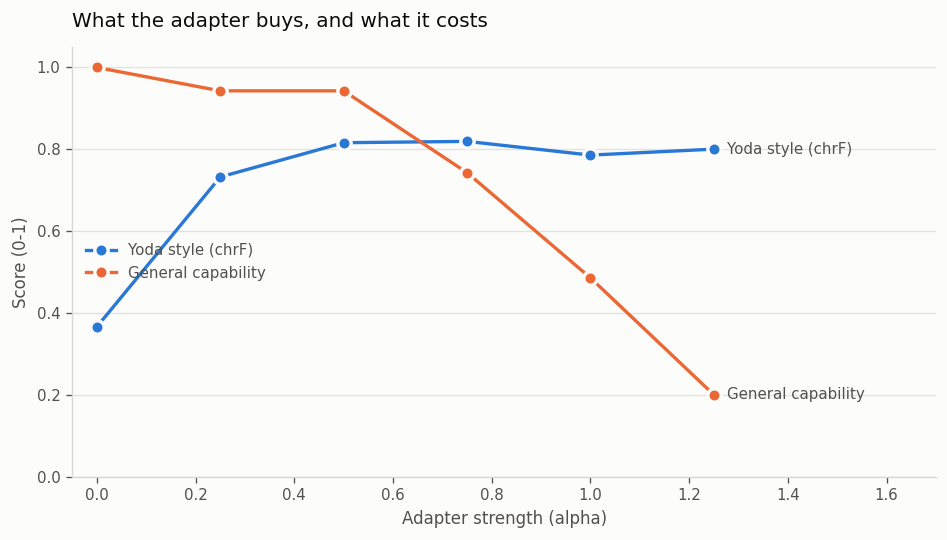

In [ ]:
import matplotlib.pyplot as plt

SURFACE, INK, INK_SOFT, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#d8d7d2"
STYLE_C, CAP_C = "#2a78d6", "#eb6834"

fig, ax = plt.subplots(figsize=(8, 4.6), dpi=120, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

x = sweep["alpha"]
ax.plot(x, sweep["style_score"], color=STYLE_C, linewidth=2, marker="o",
        markersize=8, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
ax.plot(x, sweep["capability"], color=CAP_C, linewidth=2, marker="o",
        markersize=8, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)

ax.annotate("Yoda style (chrF)", (x.iloc[-1], sweep["style_score"].iloc[-1]),
            xytext=(8, 0), textcoords="offset points", va="center",
            fontsize=9, color=INK_SOFT)
ax.annotate("General capability", (x.iloc[-1], sweep["capability"].iloc[-1]),
            xytext=(8, 0), textcoords="offset points", va="center",
            fontsize=9, color=INK_SOFT)

ax.set_xlabel("Adapter strength (alpha)", fontsize=10, color=INK_SOFT)
ax.set_ylabel("Score (0-1)", fontsize=10, color=INK_SOFT)
ax.set_title("What the adapter buys, and what it costs",
             fontsize=12, color=INK, loc="left", pad=12)
ax.set_xlim(-0.05, max(ALPHAS) + 0.45)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", color=AXIS, linewidth=0.8, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=INK_SOFT, labelsize=9)
ax.legend(["Yoda style (chrF)", "General capability"], frameon=False,
          loc="center left", fontsize=9, labelcolor=INK_SOFT)

plt.tight_layout()
plt.savefig("/content/alignment_tax_curve.png", facecolor=SURFACE, dpi=150)
plt.show()

In [13]:
# Which capabilities break, and in what order?
rows = []
for alpha in ALPHAS:
    frame = probe.copy()
    frame["correct"] = per_item[alpha]["probe_correct"]
    for category, group in frame.groupby("category"):
        rows.append({"alpha": alpha, "category": category,
                     "accuracy": float(group["correct"].mean()), "n": len(group)})

by_category = (pd.DataFrame(rows)
               .pivot(index="category", columns="alpha", values="accuracy")
               .round(3))
print("Capability accuracy by category, across adapter strength")
display(by_category)

first_break = {}
for category in by_category.index:
    row = by_category.loc[category]
    fell = [a for a in ALPHAS if row[a] < row[ALPHAS[0]]]
    first_break[category] = fell[0] if fell else None

print("\nFirst alpha at which each category drops below its baseline:")
for category, alpha in sorted(first_break.items(), key=lambda kv: (kv[1] is None, kv[1])):
    print(f"  {category:12s} {alpha if alpha is not None else 'never'}")

# The 2x2 at full strength
full = sweep[sweep["alpha"] == 1.0].iloc[0]
style_high = full["chrf"] > base_chrf_plain + 5
cap_high = full["capability"] >= base_capability - 0.05
verdict = {
    (True, True): "Well-scoped: style gained, capability held.",
    (True, False): "Classic alignment tax - lower alpha, or reduce the LoRA rank.",
    (False, True): "Undertrained: capability intact but the style did not take.",
    (False, False): "Something is wrong with the training run - inspect the loss curve.",
}[(style_high, cap_high)]
print(f"\nAt alpha=1.0: style {'up' if style_high else 'flat'}, "
      f"capability {'held' if cap_high else 'dropped'}\n-> {verdict}")

Capability accuracy by category, across adapter strength


alpha,0.00,0.25,0.50,0.75,1.00,1.25
category,,,,,,
arithmetic,1.0,0.889,1.00,0.778,0.667,0.333
factual,1.0,1.000,1.00,1.000,0.667,0.333
format,1.0,0.800,0.80,0.200,0.000,0.000
instruction,1.0,1.000,1.00,1.000,0.400,0.000
reasoning,1.0,1.000,0.75,0.250,0.250,0.000



First alpha at which each category drops below its baseline:
  arithmetic   0.25
  format       0.25
  reasoning    0.5
  factual      1.0
  instruction  1.0

At alpha=1.0: style up, capability dropped
-> Classic alignment tax - lower alpha, or reduce the LoRA rank.


In [ ]:
detail = pd.DataFrame({
    "sentence": style_sentences,
    "reference": style_references,
    "base_no_prompt": base_style_plain,
    "base_prompted": base_style_prompted,
})
for alpha in ALPHAS:
    detail[f"adapter_a{alpha}"] = per_item[alpha]["style_preds"]

detail.to_csv(RESULTS_PATH, index=False)
sweep.to_csv(RESULTS_PATH.replace(".csv", "_sweep.csv"), index=False)
by_category.to_csv(RESULTS_PATH.replace(".csv", "_by_category.csv"))

print(f"Saved per-sentence outputs to {RESULTS_PATH}")
print(f"Saved the sweep to {RESULTS_PATH.replace('.csv', '_sweep.csv')}")
print(f"Saved the category breakdown to {RESULTS_PATH.replace('.csv', '_by_category.csv')}")
display(detail.head())

Saved per-sentence outputs to /content/drive/MyDrive/344/code/QLoRA-SFT-Yoda-Genz/yoda_alignment_tax_results.csv
Saved the sweep to /content/drive/MyDrive/344/code/QLoRA-SFT-Yoda-Genz/yoda_alignment_tax_results_sweep.csv
Saved the category breakdown to /content/drive/MyDrive/344/code/QLoRA-SFT-Yoda-Genz/yoda_alignment_tax_results_by_category.csv


,sentence,reference,base_no_prompt,base_prompted,adapter_a0.0,adapter_a0.25,adapter_a0.5,adapter_a0.75,adapter_a1.0,adapter_a1.25
0,The professor uploaded the lecture slides befo...,"Before lunch, the lecture slides the professor...",The sentence provided is already in the past t...,"""Before lunch, the lecture slides were uploade...",The sentence provided is already in the past t...,"Before lunch, the professor uploaded the lectu...","Before lunch, the lecture slides the professor...","Before lunch, the lecture slides the professor...","Uploaded before lunch, the lecture slides the ...","Before lunch, the lecture slides the professor..."
1,Our robotics team finished the prototype last ...,"Last night, the prototype our robotics team fi...",Congratulations on completing the prototype fo...,"Last night, the prototype was finished by our ...",Congratulations on completing the prototype fo...,"Last night, our robotics team finished the pro...","Finished the prototype last night, our robotic...","Finished the prototype last night, our robotic...","Finished the prototype last night, our robotic...","Finished the prototype last night, our robotic..."
2,The campus bus arrived just before the rain be...,"Just before the rain began, the campus bus arr...",The campus bus arrived just before the rain be...,"Just before the rain began, the campus bus arr...",The campus bus arrived just before the rain be...,"Just before the rain began, the campus bus arr...","Just before the rain began, the campus bus arr...","Just before the rain began, the campus bus arr...","Just before the rain began, the campus bus arr...","Just before the rain began, the campus bus arr..."
3,My roommate left the apartment key on the kitc...,"On the kitchen counter, the apartment key my r...",I understand that you're concerned about the s...,"Left the apartment key on the kitchen counter,...",I understand that you're concerned about the s...,"Left the apartment key on the kitchen counter,...","Left the apartment key on the kitchen counter,...","Left the apartment key on the kitchen counter,...","The apartment key on the kitchen counter, my r...","The apartment key on the kitchen counter, left..."
4,The astronomy club will watch the meteor showe...,"Tonight, the meteor shower the astronomy club ...",The instruction is a simple directive indicati...,"""Watch the meteor shower the astronomy club wi...",The instruction is a simple directive indicati...,The astronomy club will watch the meteor showe...,"Watch the meteor shower tonight, the astronomy...","Watch the meteor shower tonight, the astronomy...","Watch the meteor shower tonight, the astronomy...","Watch the meteor shower tonight, the astronomy..."


## Final analysis

Using the curve, the category table, and the prompt-sensitivity result, write 300–400
words addressing:

1. Did the adapter cost the model any general capability at `alpha=1.0`? Quantify it.
2. Where is the knee — the strongest style you can buy before capability starts falling?
3. **Which category degraded first?** Format compliance and multi-part instructions
   usually break before factual recall. Did yours? Propose an explanation.
4. Did the adapter go prompt-deaf? What does that imply about combining a fine-tuned
   model with prompt-based control in production?
5. RAG and CAG cannot damage a model, because they never touch its weights. Given your
   numbers, when is that safety worth more than the quality a fine-tune buys?

### If you measured no degradation

That is a legitimate result, not a failed experiment. A rank-8 adapter trained on 720
short style examples is a light touch on a 3.8B model, and it may simply not disturb
general behaviour. Report it plainly and say what would make the test more sensitive —
more probe items, a harder probe, a higher rank, more epochs, or a larger `alpha` range.
Do not go looking for a drop that is not there.